In [149]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import random

In [150]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [151]:
X_train, X_test = x_train/255.0, x_test/255.0

In [158]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [153]:
model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [154]:
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=2)

training = model.fit(X_train, y_train,
                    epochs=8,
                    validation_split=0.1,
                    callbacks=[callback]
)

Epoch 1/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9089 - loss: 0.3144 - val_accuracy: 0.9665 - val_loss: 0.1206
Epoch 2/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9538 - loss: 0.1536 - val_accuracy: 0.9728 - val_loss: 0.0957
Epoch 3/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9654 - loss: 0.1135 - val_accuracy: 0.9792 - val_loss: 0.0780
Epoch 4/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9709 - loss: 0.0942 - val_accuracy: 0.9782 - val_loss: 0.0735
Epoch 5/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9751 - loss: 0.0793 - val_accuracy: 0.9772 - val_loss: 0.0803
Epoch 6/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9780 - loss: 0.0688 - val_accuracy: 0.9807 - val_loss: 0.0700
Epoch 7/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9806 - loss: 0.0616 - val_accuracy: 0.9817 - val_loss: 0.0684
Epoch 8/8
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9824 - loss: 0.0542 - val_

In [155]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9784 - loss: 0.0705
Final Test Accuracy: 97.84%


303
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


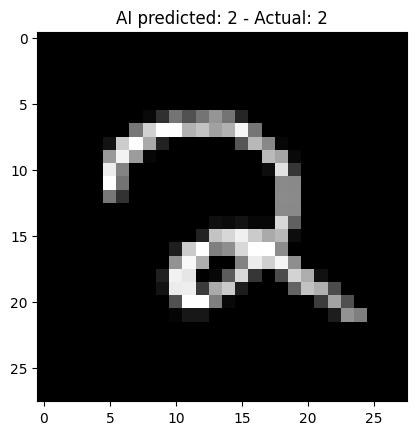

Confidence Level: 96.55%


In [156]:
random_idx = random.randint(0, len(X_test) - 1)
print(random_idx)

img_idx = X_test[random_idx]
lbl_idx = y_test[random_idx]

predictions_probs = model.predict(img_idx.reshape(1, 28, 28))
predicted_label = np.argmax(predictions_probs)

plt.imshow(img_idx, cmap='gray')
plt.title(f"AI predicted: {predicted_label} - Actual: {lbl_idx}")
plt.axis=('off')
plt.show()

confidence = predictions_probs[0][predicted_label]
print(f"Confidence Level: {confidence * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


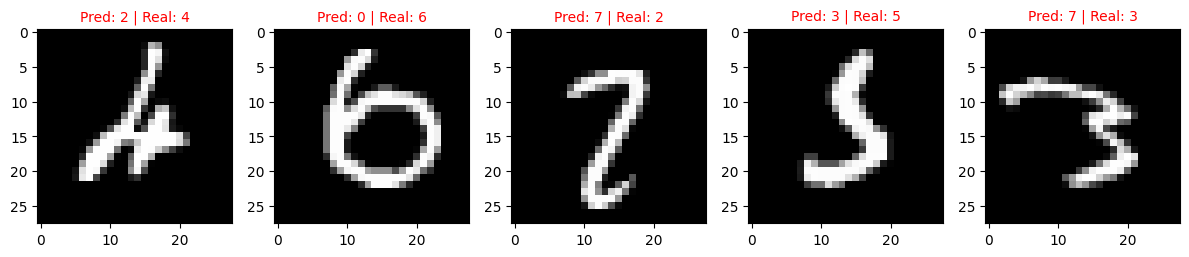

In [157]:
mistakes_found = 0
all_predictions = model.predict(X_test)
all_predicted_labels = np.argmax(all_predictions, axis=1)

plt.figure(figsize=(12, 4))

for i in range(len(X_test)):
    if all_predicted_labels[i] != y_test[i]:
        mistakes_found += 1
        
        plt.subplot(1, 5, mistakes_found)
        plt.imshow(X_test[i], cmap='gray')
        plt.title(f"Pred: {all_predicted_labels[i]} | Real: {y_test[i]}", color='red', fontsize=10)
        plt.axis='off'

        if mistakes_found == 5:
            break

plt.tight_layout()
plt.show()
